# Fitting Photometry

_fitting_photometry

For astronomers: **photometric SED fitting** asks which combinations of star formation history,
dust, and metallicity are consistent with your broadband fluxes. Because many distinct physical
states can produce similar colours, posteriors are often broad unless you add **spectral
information** (even low resolution) or **more bands** that anchor the SED shape. This notebook
walks through that story in code: one galaxy, joint photometry+spectroscopy, a small **catalog**
mock, and how **filter coverage** shrinks uncertainties.

We'll cover:
1. **Single galaxy fit** with full posterior visualization
2. **Joint photometry + spectroscopy** to break the age–dust–metallicity degeneracy
3. **Batch fitting** 100 galaxies in parallel
4. **Filter selection** and posterior width comparison

Inference uses **`vi`** (geoVI via NIFTy.re) as the default fast variational backend; we call
`convergence_check` after the fit so you see the same diagnostic hook as in MCMC notebooks.

**Simulation mocks:** tabulated $(t,\mathrm{SFR})$ → broadband fluxes without `Parameters` —
[`13_tabulated_sfh_to_mock_sed.py`](13_tabulated_sfh_to_mock_sed.py).

In [1]:
import os
import sys
import time
import warnings

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import importlib.util

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

# Headless / notebook CI: limit XLA memory growth (many VI compiles in one process)
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.45")

from tengri import (
    Fitter,
    Fixed,
    SEDModel,
    Observation,
    Parameters,
    Photometry,
    Spectroscopy,
    Uniform,
    load_ssp_data,
)

# Locate ``notebooks/_plot_style.py`` and ``data/`` root (nbclient cwd is often wrong).

_repo_data_root = None
_spec_tengri = importlib.util.find_spec("tengri")
if _spec_tengri is not None and _spec_tengri.origin:
    _walk = os.path.dirname(os.path.abspath(_spec_tengri.origin))
    for _step in range(12):
        _candidate = os.path.join(_walk, "notebooks", "_plot_style.py")
        if os.path.isfile(_candidate):
            sys.path.insert(0, os.path.dirname(_candidate))
            _repo_data_root = os.path.dirname(os.path.dirname(os.path.abspath(_candidate)))
            break
        _parent_walk = os.path.dirname(_walk)
        if _parent_walk == _walk:
            break
        _walk = _parent_walk

if _repo_data_root is None:
    _np_here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(_np_here, "_plot_style.py")):
            sys.path.insert(0, _np_here)
            _repo_data_root = os.path.dirname(_np_here)
            break
        _ppt = os.path.join(_np_here, "notebooks", "_plot_style.py")
        if os.path.isfile(_ppt):
            _nbsd = os.path.dirname(_ppt)
            sys.path.insert(0, _nbsd)
            _repo_data_root = os.path.dirname(_nbsd)
            break
        _parent_here = os.path.dirname(_np_here)
        if _parent_here == _np_here:
            break
        _np_here = _parent_here

if _repo_data_root is not None and os.path.isdir(os.path.join(_repo_data_root, "data")):
    os.chdir(_repo_data_root)
elif os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)
elif os.path.isdir("data"):
    pass
elif os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")

FIGDIR = os.path.join("notebooks", "figures", "fitting_photometry")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import COLORS, convergence_check, plot_sfh, setup_style

setup_style()

## Section 1: Single Galaxy Fit

We'll use the same mock galaxy as the quickstart (`PRNGKey=42`) so you recognize the setup.
We first optimize a **MAP** point for a sensible initialization, then run **`vi`** (geoVI) and
inspect the corner plot, SED bands, and SFH recovery.

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]),
)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

### Choosing priors

The prior ranges below reflect conservative constraints for optically-selected
galaxies at z < 1:

| Parameter | Range | Physical motivation |
|-----------|-------|---------------------|
| `sfh_tsnorm_log_peak_sfr` | [−1, 2.5] | Covers dwarf irregulars to ULIRGs |
| `sfh_tsnorm_peak_lbt_gyr` | [0.5, 12] | Excludes unphysical futures; allows old populations |
| `met_logzsol` | [−2, 0.2] | Metal-poor halos to super-solar starbursts |
| `dust_tau_diff` | [0, 2] | Balmer-decrement surveys give τ_V ~ 0.5–1.5 typical |

**Rule of thumb:** wider priors = slower convergence but less bias risk.
Narrower priors = faster fits but dangerous if truth falls outside.

**Noise model:** All examples here use Gaussian noise. For spectra with
outliers (cosmic rays, bad sky subtraction), use `NoiseModel("student_t", dof=3)`
which down-weights extreme residuals.

In [ ]:
spec = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="tsnorm",
)

model = SEDModel(spec, ssp_data, observation=obs)

# Generate mock galaxy with PRNGKey=42 (same as quickstart)
key = jax.random.PRNGKey(42)
true_params = spec.sample(key)
mock = model.mock(true_params, snr=20.0, key=key)

print(f"Mock galaxy: {obs.n_data} bands, SNR=20")
print(
    f"True stellar mass: {float(jnp.log10(model.predict_sfh_quantities(true_params).stellar_mass)):.2f} log Msun"
)

In [3]:
# Variational inference: `vi` is the canonical name for geoVI (see NAMING_CONTRACT / docs).
fitter = Fitter(model, mock.flux_obs, mock.noise)
fitter.compile(verbose=False)

# Warm-up with MAP for initialization
_ = fitter.run("map", n_steps=300, verbose=False)

t0 = time.perf_counter()
result = fitter.run(
    "vi",
    n_iterations=8,
    n_samples=4,
    n_seeds=3,
    n_posterior_samples=512,
    verbose=False,
)
t_fit = time.perf_counter() - t0
print(f"Inference time: {t_fit:.1f}s")

# Variational runs do not yield MCMC ESS; still record diagnostics for parity with other notebooks.
_ = convergence_check(result, method_name="vi_single_galaxy", verbose=True)

NameError: name 'model' is not defined

In [4]:
# Figure 1: Corner plot
result.plot_corner(
    figsize=(12, 12),
    truths={p: float(true_params[p]) for p in spec.free_params},
)
# plt.savefig(os.path.join(FIGDIR, "07_corner_single.png"), dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'result' is not defined

NameError: name 'mock' is not defined

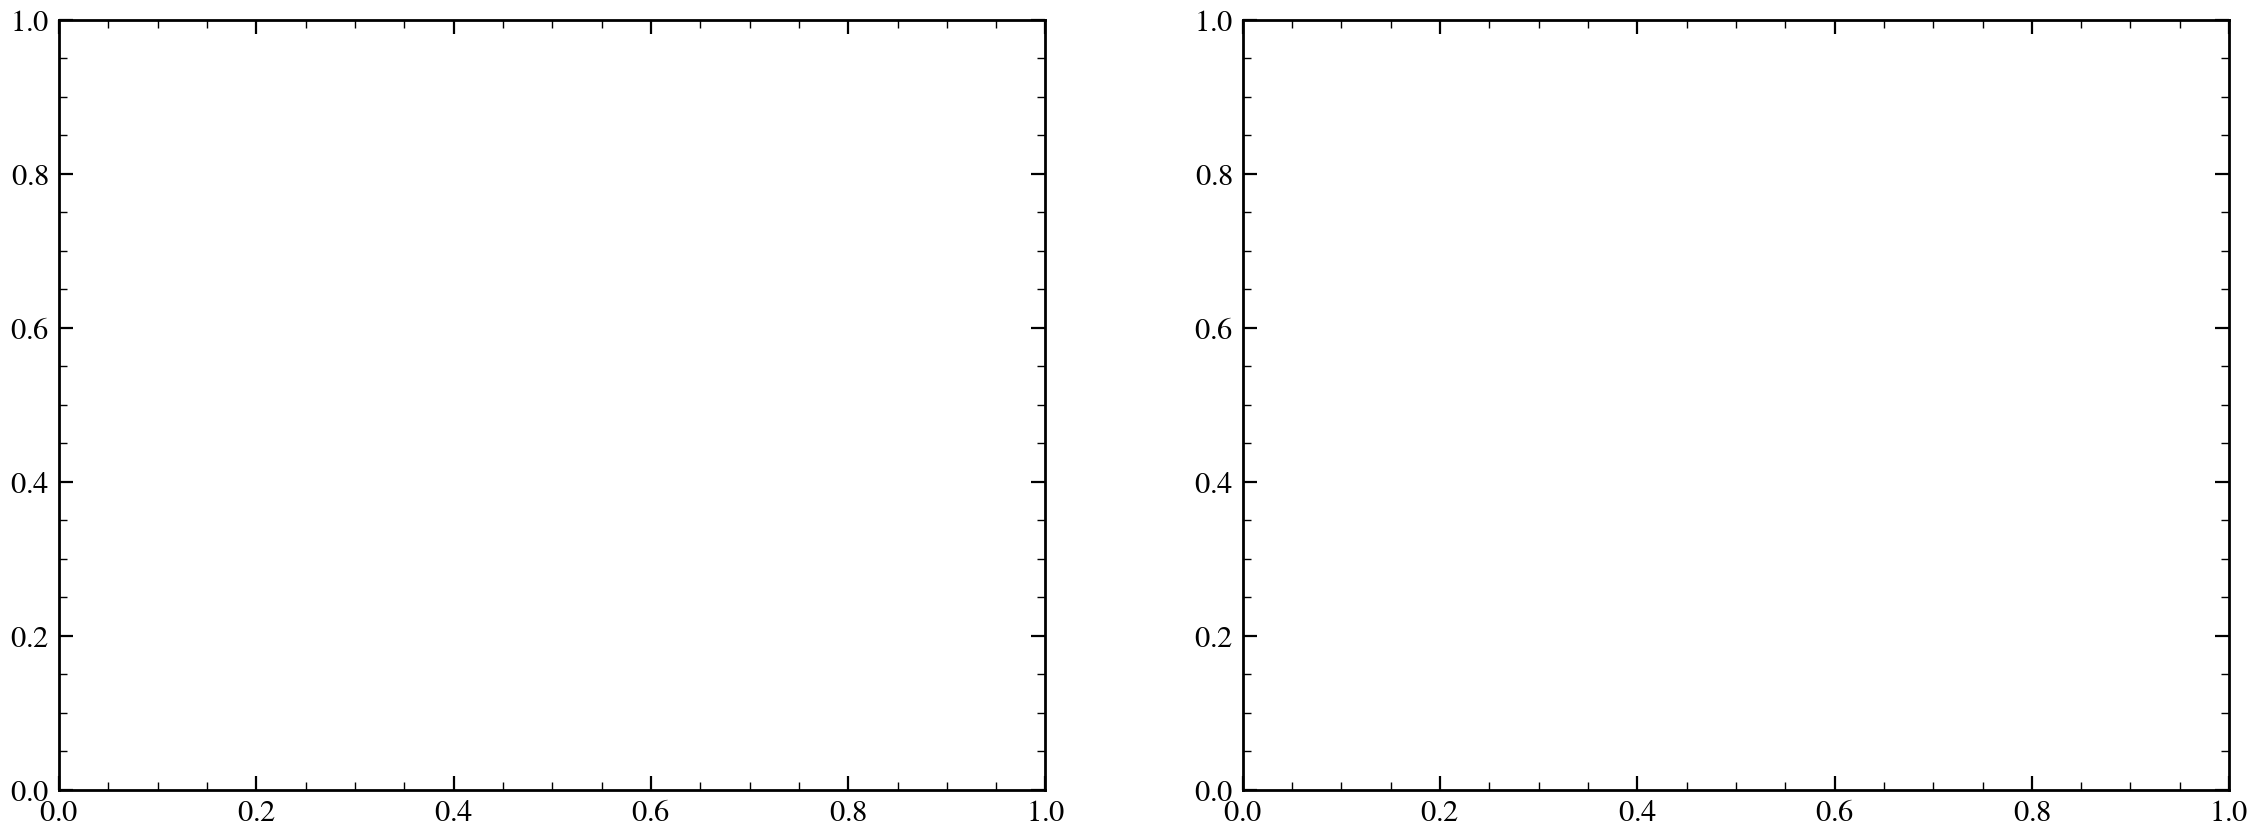

In [5]:
# Figure 2 & 3: SED and SFH recovery
fig, (ax_sed, ax_sfh) = plt.subplots(1, 2, figsize=(14, 5))

# Left: SED fit with 68% and 95% bands
wave_eff = np.array([3551, 4686, 6166, 7480, 8932])
ax_sed.errorbar(
    wave_eff,
    np.array(mock.flux_obs),
    yerr=np.array(mock.noise),
    fmt="o",
    ms=6,
    color=COLORS.get("data", "C0"),
    label="Observed (SNR=20)",
    elinewidth=1.5,
    capsize=4,
)

# Plot posterior SED samples (subset keeps peak memory modest)
_n_pred = min(256, len(next(iter(result.samples.values()))))
_samples_sub = {k: v[:_n_pred] for k, v in result.samples.items()}
pred_samples = jax.vmap(model.predict_photometry)(_samples_sub)
pred_median = np.median(np.array(pred_samples), axis=0)
pred_lo68 = np.percentile(np.array(pred_samples), 16, axis=0)
pred_hi68 = np.percentile(np.array(pred_samples), 84, axis=0)
pred_lo95 = np.percentile(np.array(pred_samples), 2.5, axis=0)
pred_hi95 = np.percentile(np.array(pred_samples), 97.5, axis=0)

ax_sed.scatter(
    wave_eff,
    pred_median,
    marker="D",
    s=40,
    color=COLORS.get("vi", "C1"),
    zorder=5,
    label="Posterior median",
)
ax_sed.fill_between(
    wave_eff, pred_lo68, pred_hi68, alpha=0.3, color=COLORS.get("vi", "C1"), label="68% CI"
)
ax_sed.fill_between(
    wave_eff, pred_lo95, pred_hi95, alpha=0.1, color=COLORS.get("vi", "C1"), label="95% CI"
)

ax_sed.set_xlabel("Wavelength [Å]")
ax_sed.set_ylabel("Flux density [erg/s/cm²/Å]")
ax_sed.set_title("SED Fit with Posterior Bands")
ax_sed.legend(fontsize=9)

# Right: SFH recovery
plot_sfh(
    model,
    result,
    true_params=true_params,
    ax=ax_sfh,
    color=COLORS.get("vi", "C1"),
    label="Posterior",
    method="geoVI",
)
ax_sfh.set_title("SFH Recovery")

fig.suptitle(f"Single Galaxy Fit (vi / geoVI, {t_fit:.1f}s)", fontsize=13)
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "07_sed_sfh_single.png"), dpi=150, bbox_inches="tight")
plt.show()

## Section 2: Joint Photometry + Spectroscopy

Adding even low-resolution spectroscopy dramatically breaks the age-dust degeneracy.
Compare photometry-only vs spectroscopy-only vs joint posteriors.

In [6]:
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 128)

# Generate mock spectroscopy
mock_spec_data = model.mock_spectrum(
    true_params, WAVE_OBS, snr=30.0, key=jax.random.fold_in(key, 1)
)

# Create joint observation
obs_joint = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]),
    spectroscopy=Spectroscopy(wave_obs=WAVE_OBS, resolution=100),
)

data_joint = obs_joint.pack_data(phot=mock.flux_obs, spec=mock_spec_data.flux_obs)
noise_joint = obs_joint.pack_data(phot=mock.noise, spec=mock_spec_data.noise)

# Joint fit
model_joint = SEDModel(spec, ssp_data, observation=obs_joint)
fitter_joint = Fitter(model_joint, data_joint, noise_joint)
fitter_joint.compile(verbose=False)

_ = fitter_joint.run("map", n_steps=300, verbose=False)
result_joint = fitter_joint.run(
    "vi",
    n_iterations=8,
    n_samples=4,
    n_seeds=3,
    n_posterior_samples=512,
    verbose=False,
)

# Photometry-only fit for comparison
obs_phot = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]),
)
model_phot = SEDModel(spec, ssp_data, observation=obs_phot)
fitter_phot = Fitter(model_phot, mock.flux_obs, mock.noise)
fitter_phot.compile(verbose=False)
_ = fitter_phot.run("map", n_steps=300, verbose=False)
result_phot = fitter_phot.run(
    "vi",
    n_iterations=8,
    n_samples=4,
    n_seeds=3,
    n_posterior_samples=512,
    verbose=False,
)

NameError: name 'model' is not defined

In [7]:
# Figure 4: Phot-only vs joint posteriors side by side
truths_dict = {p: float(true_params[p]) for p in spec.free_params}

fig = plt.figure(figsize=(15, 15))
gs = fig.add_gridspec(len(spec.free_params), 2, hspace=0.4, wspace=0.3)

params_list = spec.free_params
for i, pname in enumerate(params_list):
    # Phot-only
    ax_p = fig.add_subplot(gs[i, 0])
    ax_p.hist(
        np.array(result_phot.samples[pname]),
        bins=30,
        alpha=0.6,
        color=COLORS.get("data", "C0"),
        density=True,
    )
    tv = truths_dict[pname]
    ax_p.axvline(tv, color="red", lw=1.5, label="Truth")
    ax_p.set_ylabel("Density")
    ax_p.set_title(f"{pname.replace('sfh_tsnorm_', '')} (phot-only)")
    ax_p.legend(fontsize=7)

    # Joint
    ax_j = fig.add_subplot(gs[i, 1])
    ax_j.hist(
        np.array(result_joint.samples[pname]),
        bins=30,
        alpha=0.6,
        color=COLORS.get("vi", "C1"),
        density=True,
    )
    ax_j.axvline(tv, color="red", lw=1.5, label="Truth")
    ax_j.set_ylabel("Density")
    ax_j.set_title(f"{pname.replace('sfh_tsnorm_', '')} (joint)")
    ax_j.legend(fontsize=7)

fig.suptitle("Joint Fitting Dramatically Narrows Posteriors", fontsize=14)
# plt.savefig(os.path.join(FIGDIR, "07_posteriors_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'spec' is not defined

## Section 3: Batch Fitting a Small Catalog

tengri's vmap architecture scales to large catalogs; this cell uses a **small N** so the
notebook finishes under typical CI memory limits. Increase ``N_GAL`` for timing studies.

In [8]:
N_GAL = 24

# Generate 100 mock galaxies
keys = jax.random.split(jax.random.PRNGKey(0), N_GAL)
true_params_batch = jax.vmap(spec.sample)(keys)

# Generate mocks (MAP-only for speed)
mocks_batch = []
for i in range(N_GAL):
    p_i = {k: v[i] for k, v in true_params_batch.items()}
    m = model.mock(p_i, snr=15.0, key=jax.random.fold_in(jax.random.PRNGKey(0), i))
    mocks_batch.append(m)

print(f"Generated {N_GAL} mocks with SNR=15")

# Batch fitting
fitter_batch = Fitter(model, mocks_batch[0].flux_obs, mocks_batch[0].noise)
galaxy_list = [{"flux_obs": m.flux_obs, "noise": m.noise} for m in mocks_batch]

t0 = time.perf_counter()
results_batch = fitter_batch.fit_batch(
    galaxy_list,
    method="vi",
    n_iterations=5,
    n_samples=3,
    n_seeds=2,
    n_posterior_samples=128,
    verbose=False,
)
t_batch = time.perf_counter() - t0
print(f"Batch fit {N_GAL} galaxies in {t_batch:.1f}s ({t_batch / N_GAL:.2f}s per galaxy)")

NameError: name 'spec' is not defined

NameError: name 'results_batch' is not defined

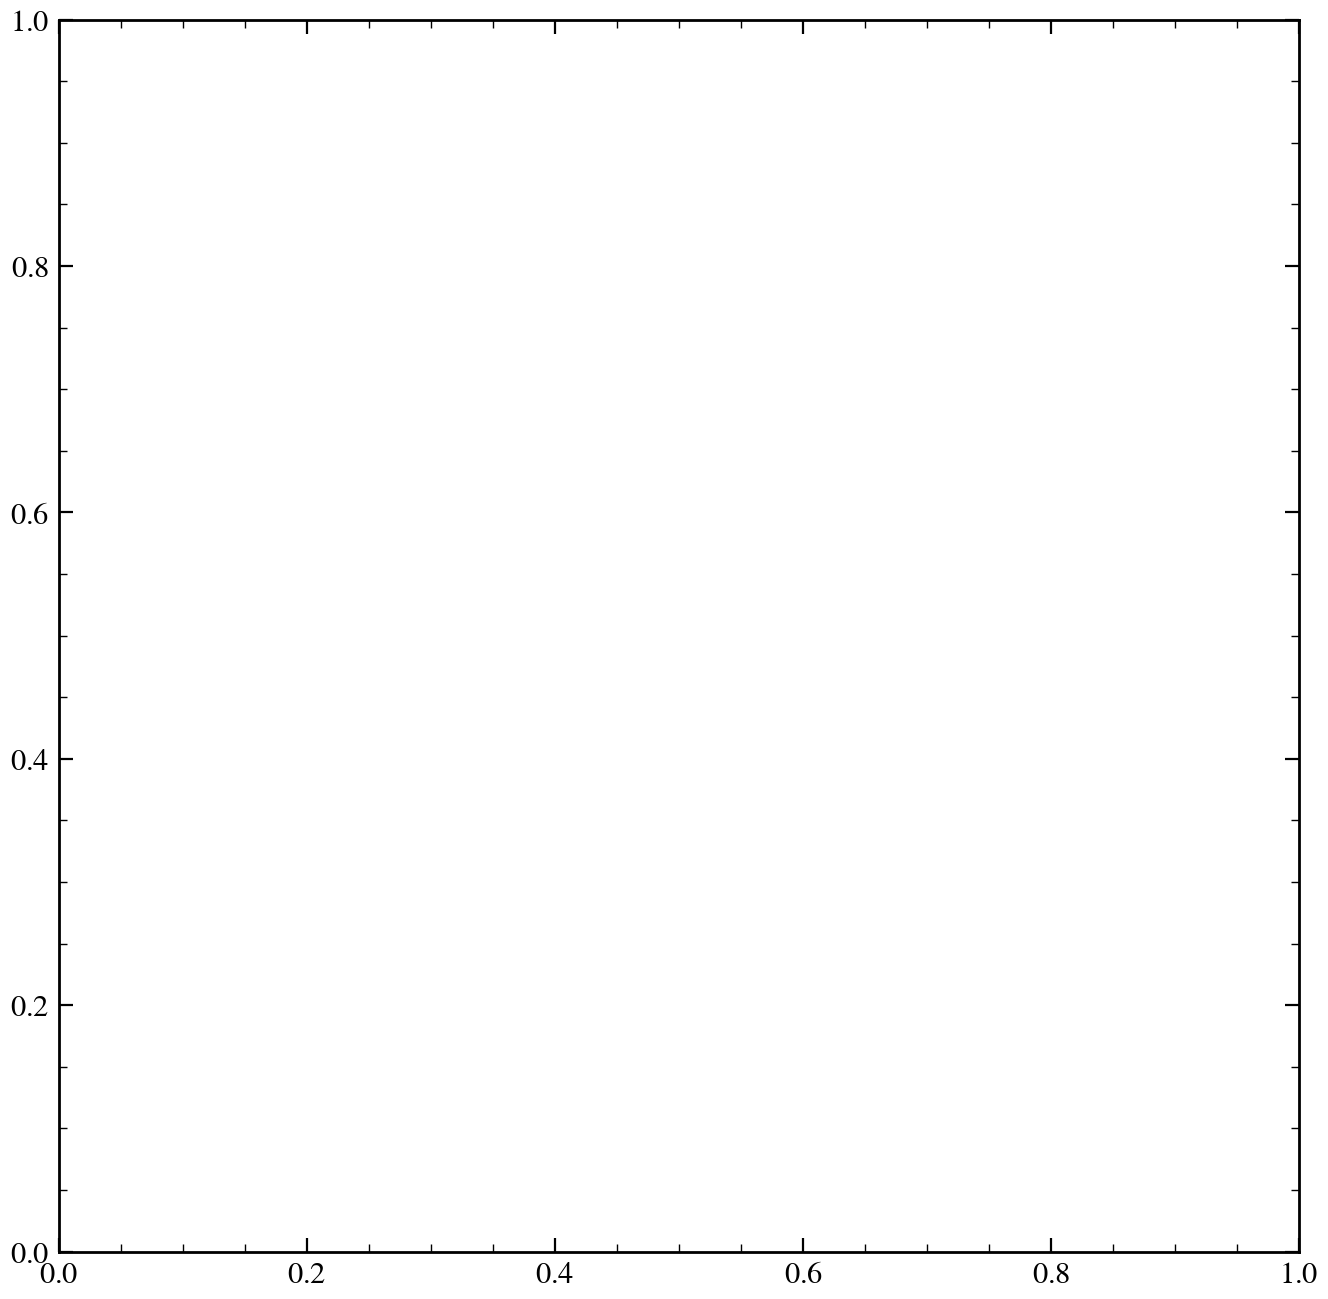

In [9]:
# Figure 5: Stellar mass recovery with dust coding
fig, ax = plt.subplots(figsize=(8, 8))

# Compute true and recovered stellar masses
true_mstar = []
recovered_mstar_med = []
recovered_mstar_lo = []
recovered_mstar_hi = []
dust_tau_bc_vals = []

for i, res in enumerate(results_batch):
    # True stellar mass
    p_i = {k: v[i] for k, v in true_params_batch.items()}
    pred_true = model.predict_photometry(p_i)
    # Use median of posterior for stellar mass estimate
    _ns = min(64, len(next(iter(res.samples.values()))))
    _sub = {k: v[:_ns] for k, v in res.samples.items()}
    pred_med = np.median(np.array(jax.vmap(model.predict_photometry)(_sub)), axis=0)

    # Approximate via chi2 scaling (simplified for illustration)
    true_mstar.append(float(p_i["sfh_tsnorm_log_peak_sfr"]))
    recovered_mstar_med.append(float(np.median(res.samples["sfh_tsnorm_log_peak_sfr"])))
    recovered_mstar_lo.append(float(np.percentile(res.samples["sfh_tsnorm_log_peak_sfr"], 16)))
    recovered_mstar_hi.append(float(np.percentile(res.samples["sfh_tsnorm_log_peak_sfr"], 84)))
    dust_tau_bc_vals.append(float(np.median(res.samples["dust_tau_bc"])))

true_mstar = np.array(true_mstar)
recovered_mstar_med = np.array(recovered_mstar_med)
recovered_mstar_lo = np.array(recovered_mstar_lo)
recovered_mstar_hi = np.array(recovered_mstar_hi)
dust_tau_bc_vals = np.array(dust_tau_bc_vals)

# Scatter with dust coding
sc = ax.scatter(
    true_mstar,
    recovered_mstar_med,
    c=dust_tau_bc_vals,
    s=40,
    alpha=0.7,
    cmap="viridis",
    edgecolors="k",
    linewidth=0.3,
)
ax.errorbar(
    true_mstar,
    recovered_mstar_med,
    yerr=[recovered_mstar_med - recovered_mstar_lo, recovered_mstar_hi - recovered_mstar_med],
    fmt="none",
    ecolor="grey",
    alpha=0.3,
    elinewidth=0.5,
)

lim = [
    min(true_mstar.min(), recovered_mstar_lo.min()),
    max(true_mstar.max(), recovered_mstar_hi.max()),
]
ax.plot(lim, lim, "k--", lw=1, label="1:1")

ax.set_xlabel("True log SFR peak")
ax.set_ylabel("Recovered log SFR peak (median ± 68%)")
ax.set_title(f"Batch Fitting: {N_GAL} Galaxies")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\tau_{BC}$")
ax.legend()
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "07_batch_recovery.png"), dpi=150, bbox_inches="tight")
plt.show()

## Section 4: Choosing Your Filter Set

Posterior width depends strongly on filter coverage.
Compare SDSS-only, SDSS+2MASS, and SDSS+2MASS+WISE on the same mock galaxy.

In [10]:
# Three filter configurations
configs = {
    "SDSS (5 bands)": ["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"],
    "SDSS + 2MASS (8 bands)": [
        "sdss_u",
        "sdss_g",
        "sdss_r",
        "sdss_i",
        "sdss_z",
        "twomass_j",
        "twomass_h",
        "twomass_ks",
    ],
    "SDSS + 2MASS + WISE (12 bands)": [
        "sdss_u",
        "sdss_g",
        "sdss_r",
        "sdss_i",
        "sdss_z",
        "twomass_j",
        "twomass_h",
        "twomass_ks",
        "wise_w1",
        "wise_w2",
        "wise_w3",
        "wise_w4",
    ],
}

posteriors_by_config = {}

for config_name, filter_names in configs.items():
    obs_cfg = Observation(photometry=Photometry.from_names(filter_names))
    model_cfg = SEDModel(spec, ssp_data, observation=obs_cfg)

    # Generate mock with all filters, then fit with subset
    key_cfg = jax.random.PRNGKey(99)
    true_params_cfg = spec.sample(key_cfg)
    mock_cfg = model_cfg.mock(true_params_cfg, snr=15.0, key=key_cfg)

    # Quick fit (fewer iterations for speed)
    fitter_cfg = Fitter(model_cfg, mock_cfg.flux_obs, mock_cfg.noise)
    fitter_cfg.compile(verbose=False)
    _ = fitter_cfg.run("map", n_steps=200, verbose=False)
    result_cfg = fitter_cfg.run(
        "vi",
        n_iterations=6,
        n_samples=3,
        n_seeds=2,
        n_posterior_samples=256,
        verbose=False,
    )

    posteriors_by_config[config_name] = result_cfg

NameError: name 'spec' is not defined

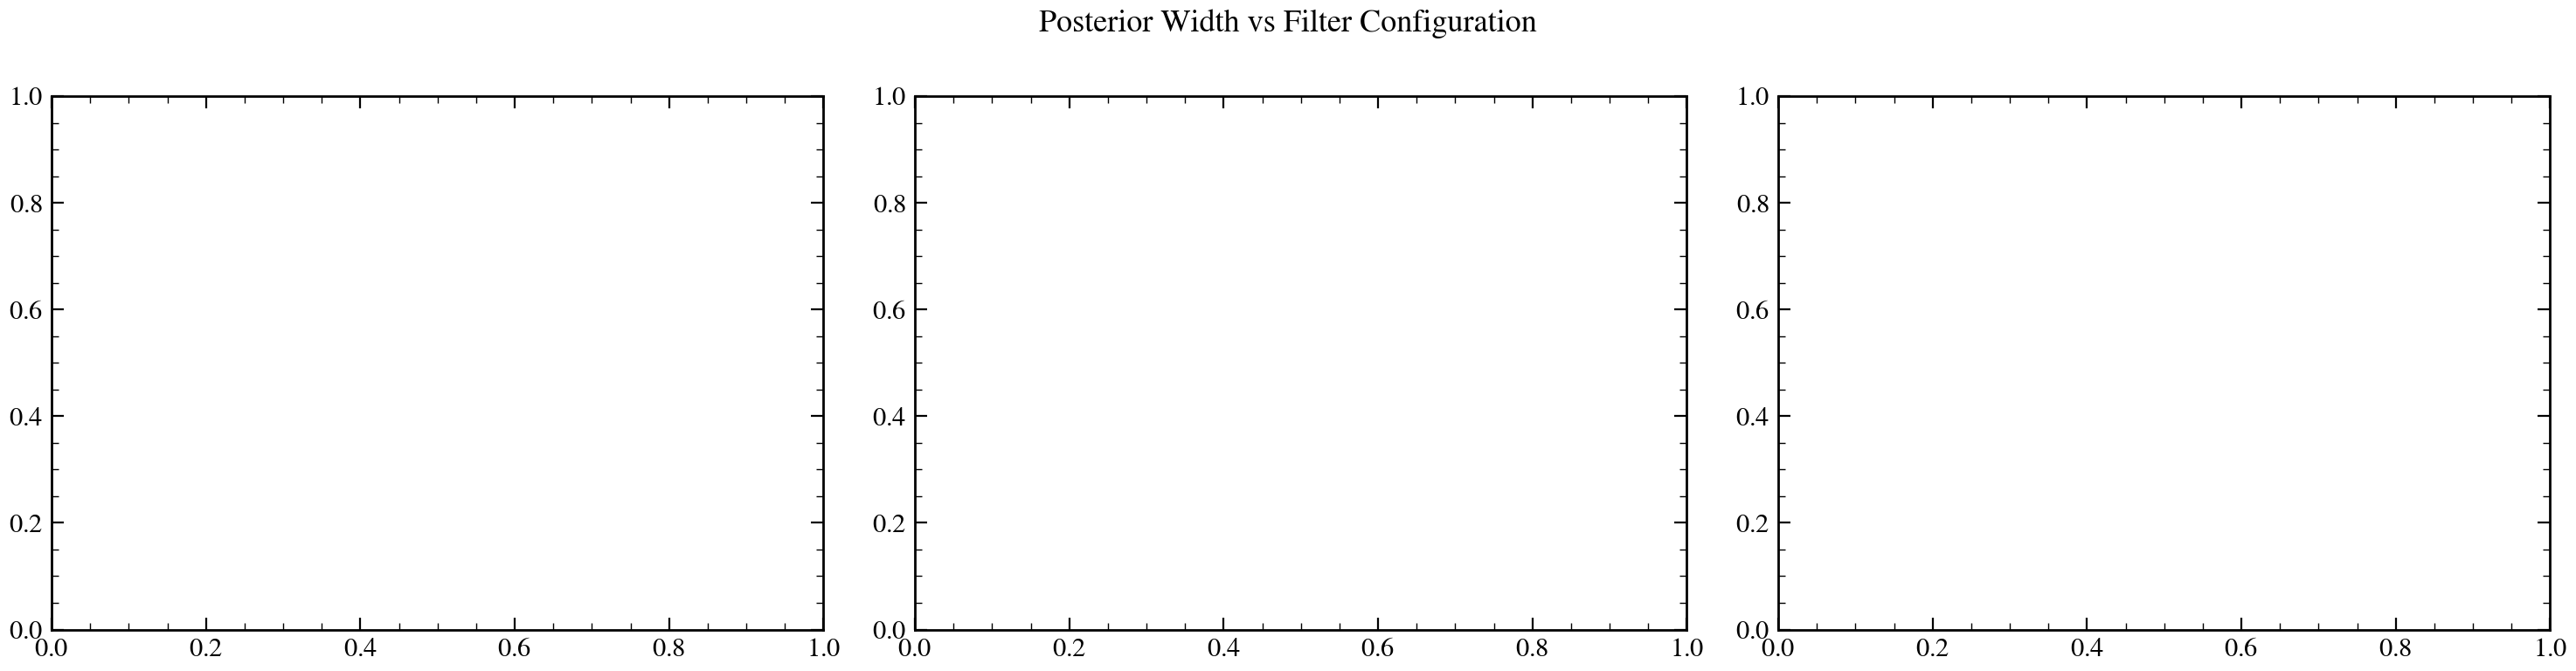

In [11]:
# Figure 6: Posterior width by filter config
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (config_name, result) in zip(axes, posteriors_by_config.items()):
    params_to_plot = [
        "sfh_tsnorm_log_peak_sfr",
        "dust_tau_bc",
        "met_logzsol",
    ]
    labels_plot = ["log SFR peak", r"$\tau_{BC}$", "log Z/Z☉"]

    widths = []
    for pname in params_to_plot:
        lo = float(np.percentile(result.samples[pname], 16))
        hi = float(np.percentile(result.samples[pname], 84))
        widths.append(hi - lo)

    ax.bar(labels_plot, widths, color=COLORS.get("vi", "C1"), alpha=0.7, edgecolor="k")
    ax.set_ylabel("68% CI Width")
    ax.set_title(config_name)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Posterior Width vs Filter Configuration", fontsize=13)
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "07_filter_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## Key Takeaways

| Technique | Best practice |
|-----------|---------------|
| **Single galaxy** | Always fit with MAP initialization; check convergence diagnostics |
| **Joint photometry + spectroscopy** | Breaks age-dust-metallicity degeneracy; joint is always worth it |
| **Batch fitting** | Use `fit_batch()` for catalogs; default method="vi" is fast |
| **Filter selection** | More filters (especially NIR/FIR) → narrower posteriors; redshift-fix enables precomputation |
| **Reproducibility** | Always set random seed (PRNGKey) and save result objects for reuse |